In [1]:
# ============================================================
# CAPSTONE PROJECT - DATA SCIENCE PGC
# Script 1: Web Scraping - Books to Scrape
# Website: https://books.toscrape.com
# ============================================================

import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

BASE_URL = "https://books.toscrape.com/catalogue/"
START_URL = "https://books.toscrape.com/catalogue/page-1.html"

RATING_MAP = {"One": 1, "Two": 2, "Three": 3, "Four": 4, "Five": 5}

books = []

def scrape_book_detail(book_url):
    """Scrape individual book page for extra details."""
    try:
        res = requests.get(book_url, timeout=10)
        soup = BeautifulSoup(res.text, "html.parser")

        # Genre / Category
        breadcrumb = soup.select("ul.breadcrumb li")
        genre = breadcrumb[-2].text.strip() if len(breadcrumb) >= 3 else "Unknown"

        # Table data
        table = soup.find("table", class_="table-striped")
        table_data = {}
        if table:
            for row in table.find_all("tr"):
                header = row.find("th").text.strip()
                value = row.find("td").text.strip()
                table_data[header] = value

        availability = table_data.get("Availability", "Unknown")
        num_in_stock = ''.join(filter(str.isdigit, availability))
        num_in_stock = int(num_in_stock) if num_in_stock else 0
        num_reviews = int(table_data.get("Number of reviews", 0))

        # Description
        desc_tag = soup.find("div", id="product_description")
        description = desc_tag.find_next_sibling("p").text.strip() if desc_tag else ""

        return genre, num_in_stock, num_reviews, description
    except Exception as e:
        print(f"  [Detail Error] {e}")
        return "Unknown", 0, 0, ""


def scrape_all_books():
    url = START_URL
    page = 1

    while url:
        print(f"Scraping page {page}...")
        try:
            res = requests.get(url, timeout=10)
            soup = BeautifulSoup(res.text, "html.parser")
        except Exception as e:
            print(f"  [Page Error] {e}")
            break

        book_cards = soup.select("article.product_pod")

        for card in book_cards:
            # Title
            title = card.h3.a["title"]

            # Price
            price_str = card.select_one("p.price_color").text.strip()
            price = float(price_str.replace("£", "").replace("Â", "").strip())

            # Rating
            rating_word = card.p["class"][1]
            rating = RATING_MAP.get(rating_word, 0)

            # Availability
            avail = card.select_one("p.availability").text.strip()

            # Book detail URL
            relative_url = card.h3.a["href"].replace("../", "")
            book_url = BASE_URL + relative_url

            # Get detail page info
            genre, num_in_stock, num_reviews, description = scrape_book_detail(book_url)

            books.append({
                "title": title,
                "price_gbp": price,
                "rating": rating,
                "rating_label": rating_word,
                "availability": avail,
                "num_in_stock": num_in_stock,
                "num_reviews": num_reviews,
                "genre": genre,
                "description": description,
                "url": book_url
            })

            time.sleep(0.05)  # polite delay

        # Find next page
        next_btn = soup.select_one("li.next a")
        if next_btn:
            next_href = next_btn["href"]
            url = BASE_URL + next_href
            page += 1
        else:
            url = None

    print(f"\n✅ Total books scraped: {len(books)}")
    return books


if __name__ == "__main__":
    data = scrape_all_books()
    df = pd.DataFrame(data)
    df.to_csv("books_raw.csv", index=False)
    print("✅ Data saved to books_raw.csv")
    print(df.head())
    print(f"\nShape: {df.shape}")
    print(df.dtypes)

Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
Scraping page 11...
Scraping page 12...
Scraping page 13...
Scraping page 14...
Scraping page 15...
Scraping page 16...
Scraping page 17...
Scraping page 18...
Scraping page 19...
Scraping page 20...
Scraping page 21...
Scraping page 22...
Scraping page 23...
Scraping page 24...
Scraping page 25...
Scraping page 26...
Scraping page 27...
Scraping page 28...
Scraping page 29...
Scraping page 30...
Scraping page 31...
Scraping page 32...
Scraping page 33...
Scraping page 34...
Scraping page 35...
Scraping page 36...
Scraping page 37...
Scraping page 38...
Scraping page 39...
Scraping page 40...
Scraping page 41...
Scraping page 42...
Scraping page 43...
Scraping page 44...
Scraping page 45...
Scraping page 46...
Scraping page 47...
Scraping page 48...
Scraping page 49...
Scraping page 50...

✅ Total 

In [2]:
!pip install requests beautifulsoup4 pandas dash dash-bootstrap-components scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 14.0 MB/s eta 0:00:00


In [3]:
!pip install requests beautifulsoup4 pandas dash dash-bootstrap-components scikit-learn

In [4]:
!pip install dash dash-bootstrap-components

Raw Shape: (1000, 10)
                                   title  price_gbp  rating rating_label  \
0                   A Light in the Attic      51.77       3        Three   
1                     Tipping the Velvet      53.74       1          One   
2                             Soumission      50.10       1          One   
3                          Sharp Objects      47.82       4         Four   
4  Sapiens: A Brief History of Humankind      54.23       5         Five   

  availability  num_in_stock  num_reviews               genre  \
0     In stock            22            0              Poetry   
1     In stock            20            0  Historical Fiction   
2     In stock            20            0             Fiction   
3     In stock            20            0             Mystery   
4     In stock            20            0             History   

                                         description  \
0  It's hard to imagine a world without A Light i...   
1  "Erotic and abs

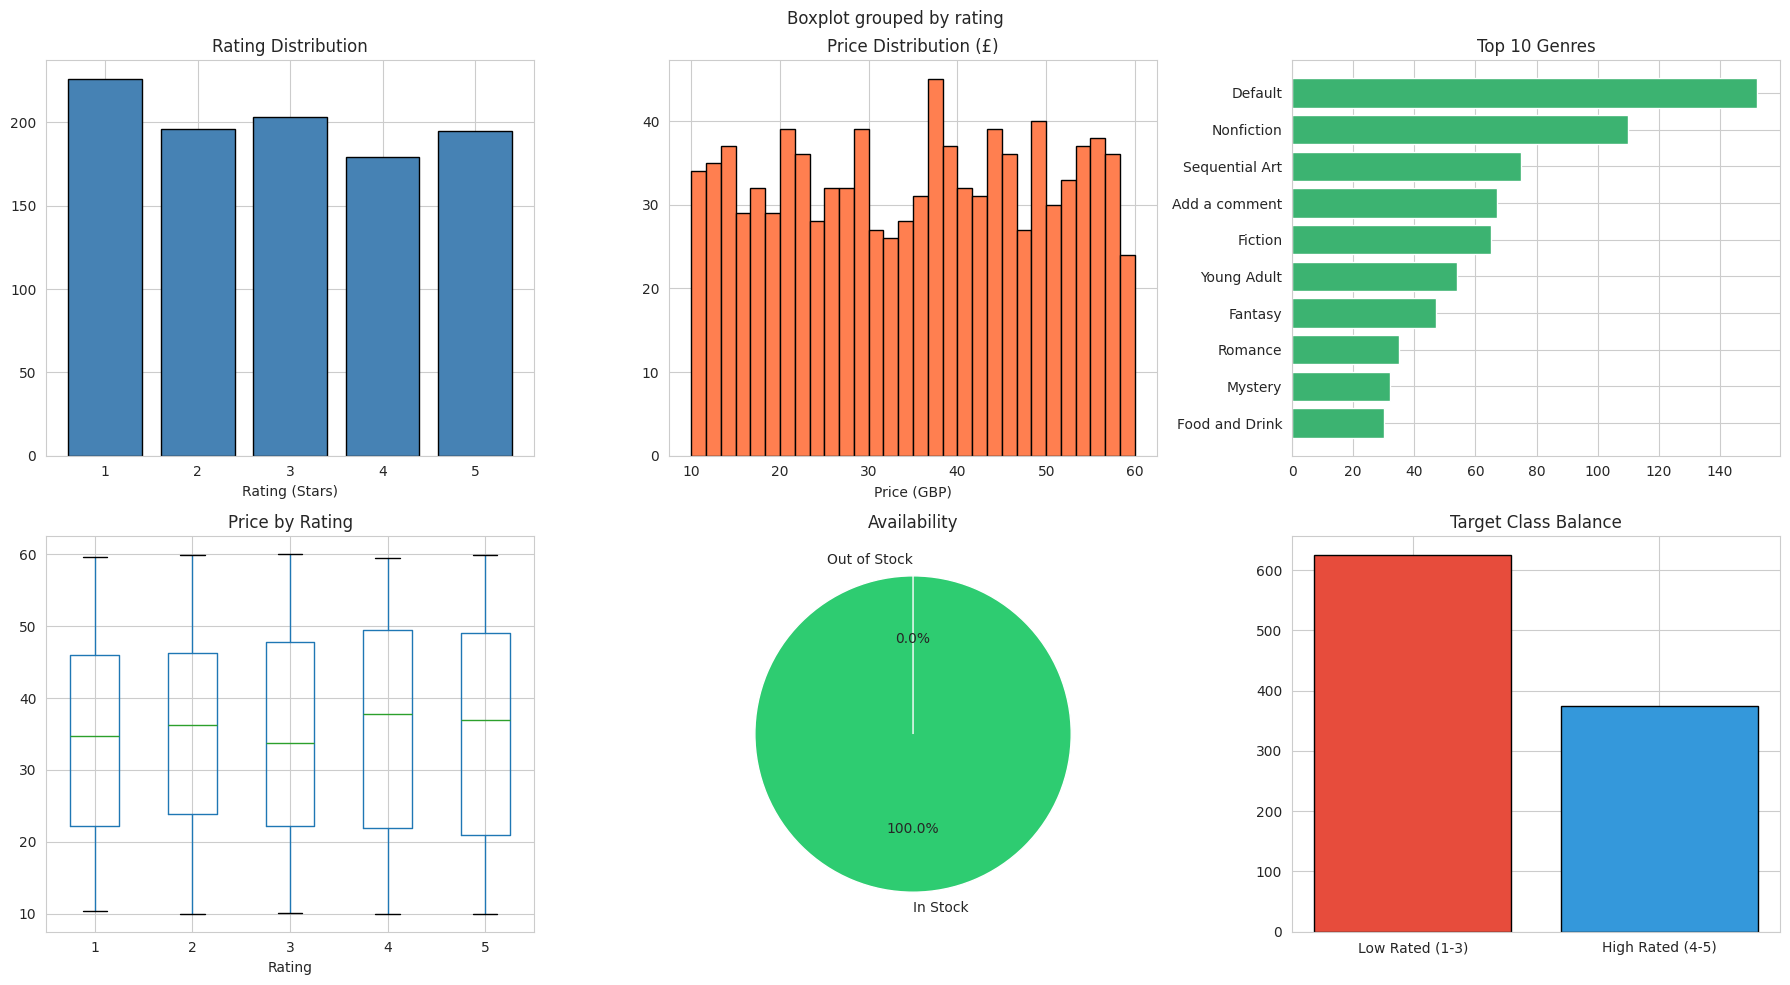

✅ Saved eda_overview.png


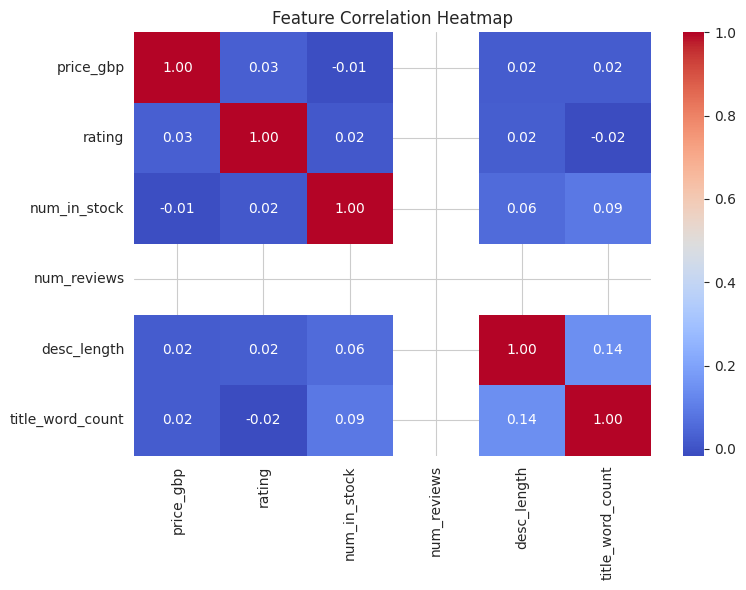

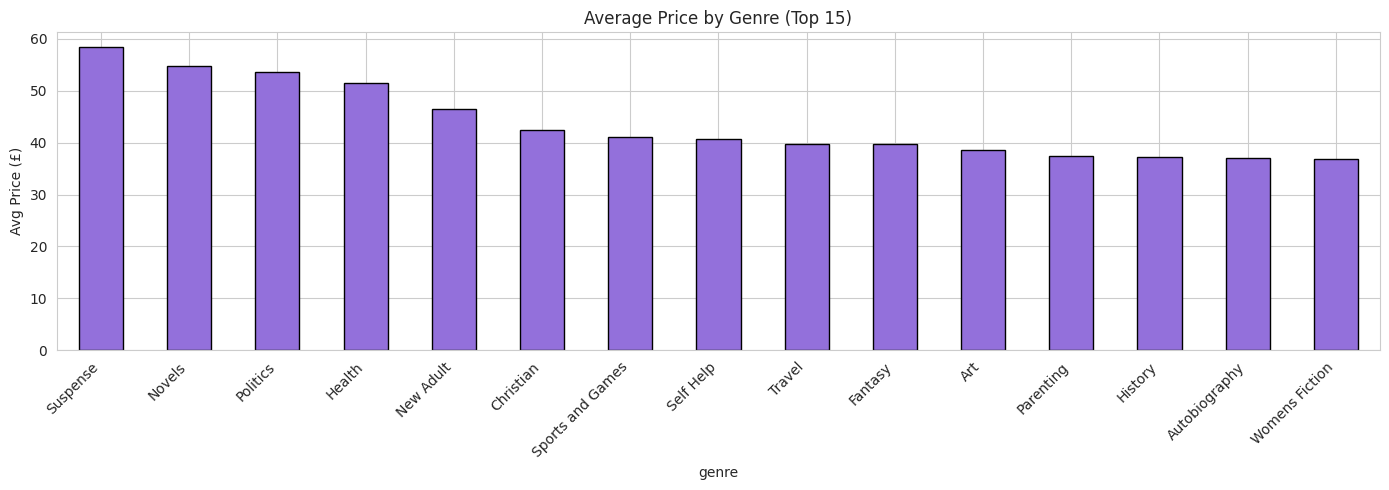


Train size: (799, 7), Test size: (200, 7)
Class balance (train):
high_rated
0    500
1    299
Name: count, dtype: int64

Logistic Regression
  Accuracy : 0.6250
  ROC-AUC  : 0.5059
  CV Acc   : 0.6256
              precision    recall  f1-score   support

   Low Rated       0.62      1.00      0.77       125
  High Rated       0.00      0.00      0.00        75

    accuracy                           0.62       200
   macro avg       0.31      0.50      0.38       200
weighted avg       0.39      0.62      0.48       200


Random Forest
  Accuracy : 0.6200
  ROC-AUC  : 0.4988
  CV Acc   : 0.6006
              precision    recall  f1-score   support

   Low Rated       0.63      0.93      0.75       125
  High Rated       0.47      0.11      0.17        75

    accuracy                           0.62       200
   macro avg       0.55      0.52      0.46       200
weighted avg       0.57      0.62      0.54       200


Gradient Boosting
  Accuracy : 0.5800
  ROC-AUC  : 0.4699
  CV Acc  

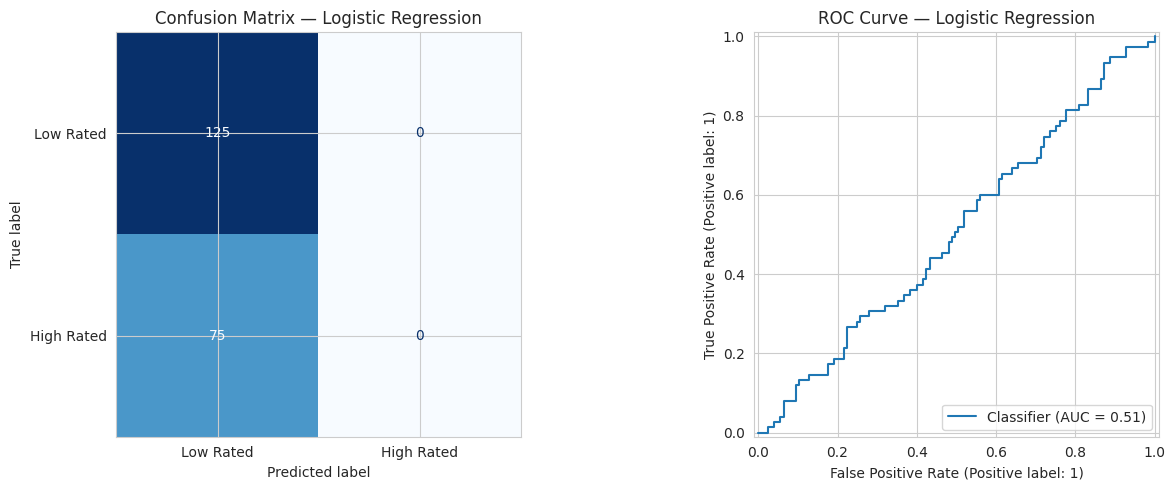

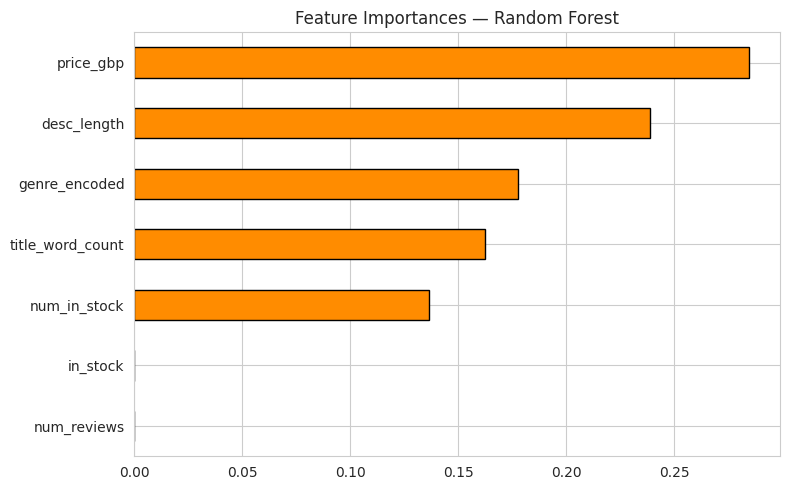


Model Comparison:
                      Accuracy  ROC-AUC  CV Accuracy
Logistic Regression     0.625   0.5059       0.6256
Random Forest           0.620   0.4988       0.6006
Gradient Boosting       0.580   0.4699       0.5706
Dash is running on http://127.0.0.1:8050/



INFO:dash.dash:Dash is running on http://127.0.0.1:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:8050
INFO:werkzeug:Press CTRL+C to quit


In [ ]:
# CAPSTONE PROJECT - DATA SCIENCE PGC
# Script 2: Cleaning, EDA, Model Building & Plotly Dash Dashboard
# ============================================================

# ── CELL 1: Install dependencies (run once in Colab) ────────
# !pip install dash dash-bootstrap-components scikit-learn imbalanced-learn

# ── CELL 2: Imports ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              RocCurveDisplay, accuracy_score)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

# ── CELL 3: Load & Preview Raw Data ─────────────────────────
df_raw = pd.read_csv("books_raw.csv")
print("Raw Shape:", df_raw.shape)
print(df_raw.head())
print(df_raw.info())
print(df_raw.describe())
print("\nMissing values:\n", df_raw.isnull().sum())
print("\nDuplicates:", df_raw.duplicated().sum())

# ── CELL 4: Data Cleaning & Preprocessing ───────────────────
df = df_raw.copy()

# 1. Drop duplicates
df.drop_duplicates(subset="title", inplace=True)

# 2. Handle missing values
df["genre"].fillna("Unknown", inplace=True)
df["description"].fillna("", inplace=True)
df["num_reviews"].fillna(0, inplace=True)
df["num_in_stock"].fillna(0, inplace=True)

# 3. Standardise availability column
df["in_stock"] = df["availability"].str.contains("In stock", case=False).astype(int)

# 4. Feature Engineering
# Price buckets
df["price_bucket"] = pd.cut(df["price_gbp"],
                             bins=[0, 10, 20, 30, 40, 60],
                             labels=["<£10", "£10-20", "£20-30", "£30-40", "£40+"])

# High-rated label (target): 1 if rating >= 4, else 0
df["high_rated"] = (df["rating"] >= 4).astype(int)

# Description length
df["desc_length"] = df["description"].apply(len)

# Title word count
df["title_word_count"] = df["title"].apply(lambda x: len(x.split()))

# Genre encoding for model
le_genre = LabelEncoder()
df["genre_encoded"] = le_genre.fit_transform(df["genre"])

print("\nCleaned Shape:", df.shape)
print(df.head())
df.to_csv("books_clean.csv", index=False)
print("✅ Saved books_clean.csv")

# ── CELL 5: EDA ─────────────────────────────────────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Books Data - Exploratory Data Analysis", fontsize=16, fontweight="bold")

# 1. Rating Distribution
axes[0,0].bar(df["rating"].value_counts().sort_index().index,
              df["rating"].value_counts().sort_index().values,
              color="steelblue", edgecolor="black")
axes[0,0].set_title("Rating Distribution"); axes[0,0].set_xlabel("Rating (Stars)")

# 2. Price Distribution
axes[0,1].hist(df["price_gbp"], bins=30, color="coral", edgecolor="black")
axes[0,1].set_title("Price Distribution (£)"); axes[0,1].set_xlabel("Price (GBP)")

# 3. Top 10 Genres
top_genres = df["genre"].value_counts().head(10)
axes[0,2].barh(top_genres.index, top_genres.values, color="mediumseagreen")
axes[0,2].set_title("Top 10 Genres"); axes[0,2].invert_yaxis()

# 4. Price vs Rating Boxplot
df.boxplot(column="price_gbp", by="rating", ax=axes[1,0])
axes[1,0].set_title("Price by Rating"); axes[1,0].set_xlabel("Rating")
plt.sca(axes[1,0]); plt.title("Price by Rating")

# 5. In-Stock vs Out-of-Stock
stock_counts = df["in_stock"].value_counts().reindex([1, 0], fill_value=0)
stock_labels = ["In Stock", "Out of Stock"]
axes[1,1].pie(stock_counts.values, labels=stock_labels, autopct="%1.1f%%",
              colors=["#2ecc71","#e74c3c"], startangle=90)
axes[1,1].set_title("Availability")

# 6. High-Rated Class Balance
hr_counts = df["high_rated"].value_counts()
axes[1,2].bar(["Low Rated (1-3)", "High Rated (4-5)"], hr_counts.values,
              color=["#e74c3c","#3498db"], edgecolor="black")
axes[1,2].set_title("Target Class Balance")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved eda_overview.png")

# Correlation heatmap
plt.figure(figsize=(8,6))
num_cols = ["price_gbp","rating","num_in_stock","num_reviews","desc_length","title_word_count"]
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Genre avg price
plt.figure(figsize=(14,5))
genre_price = df.groupby("genre")["price_gbp"].mean().sort_values(ascending=False).head(15)
genre_price.plot(kind="bar", color="mediumpurple", edgecolor="black")
plt.title("Average Price by Genre (Top 15)")
plt.ylabel("Avg Price (£)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("genre_avg_price.png", dpi=150, bbox_inches="tight")
plt.show()

# ── CELL 6: Model Building ───────────────────────────────────
FEATURES = ["price_gbp", "num_in_stock", "num_reviews",
            "desc_length", "title_word_count", "genre_encoded", "in_stock"]
TARGET = "high_rated"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Class balance (train):\n{y_train.value_counts()}")

# --- Three models ---
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=500, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=8, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=4, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    acc  = accuracy_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_prob)
    cv   = cross_val_score(model, X, y, cv=5, scoring="accuracy").mean()
    results[name] = {"Accuracy": acc, "ROC-AUC": auc, "CV Accuracy": cv,
                     "model": model, "y_pred": y_pred, "y_prob": y_prob}
    print(f"\n{'='*40}\n{name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(f"  CV Acc   : {cv:.4f}")
    print(classification_report(y_test, y_pred,
                                 target_names=["Low Rated","High Rated"]))

# Best model
best_name = max(results, key=lambda k: results[k]["ROC-AUC"])
best_model = results[best_name]["model"]
print(f"\n🏆 Best Model: {best_name}")

# Confusion matrix for best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, results[best_name]["y_pred"],
    display_labels=["Low Rated","High Rated"],
    ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix — {best_name}")

RocCurveDisplay.from_predictions(
    y_test, results[best_name]["y_prob"], ax=axes[1])
axes[1].set_title(f"ROC Curve — {best_name}")
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

# Feature Importance (Random Forest)
rf = results["Random Forest"]["model"]
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
plt.figure(figsize=(8,5))
importances.plot(kind="barh", color="darkorange", edgecolor="black")
plt.title("Feature Importances — Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# Model comparison table
results_df = pd.DataFrame({k: {"Accuracy": v["Accuracy"],
                                "ROC-AUC": v["ROC-AUC"],
                                "CV Accuracy": v["CV Accuracy"]}
                            for k, v in results.items()}).T
print("\nModel Comparison:\n", results_df.round(4))

# ── CELL 7: Plotly Dash Dashboard ───────────────────────────
# Run this cell last. In Colab use: app.run(jupyter_mode="inline")
# or ngrok for public URL.

import plotly.express as px
import plotly.graph_objects as go
from dash import Dash, dcc, html, Input, Output
import dash_bootstrap_components as dbc

# Precompute data for dashboard
genre_counts     = df["genre"].value_counts().reset_index()
genre_counts.columns = ["genre", "count"]

rating_dist      = df["rating"].value_counts().sort_index().reset_index()
rating_dist.columns = ["rating", "count"]

price_bucket_avg = df.groupby("price_bucket", observed=True)["rating"].mean().reset_index()
genre_price_df   = df.groupby("genre")["price_gbp"].mean().reset_index().sort_values(
                       "price_gbp", ascending=False).head(15)

model_comp = results_df.reset_index().rename(columns={"index": "Model"})

# KPI values
total_books    = len(df)
avg_price      = df["price_gbp"].mean()
avg_rating     = df["rating"].mean()
pct_high_rated = df["high_rated"].mean() * 100

# ---- App Layout ----
app = Dash(__name__, external_stylesheets=[dbc.themes.DARKLY])

app.layout = dbc.Container([

    # ── Header ──────────────────────────────────────────────
    dbc.Row([
        dbc.Col(html.H2("📚 Books Analytics Dashboard",
                        className="text-center text-warning my-3"))
    ]),
    dbc.Row([
        dbc.Col(html.H6("Capstone Project | Data Science PGC | books.toscrape.com",
                        className="text-center text-muted mb-4"))
    ]),

    # ── KPI Cards ───────────────────────────────────────────
    dbc.Row([
        dbc.Col(dbc.Card([dbc.CardBody([
            html.H4(f"{total_books:,}", className="text-info"),
            html.P("Total Books", className="text-muted")])]),
            width=3),
        dbc.Col(dbc.Card([dbc.CardBody([
            html.H4(f"£{avg_price:.2f}", className="text-success"),
            html.P("Avg Price (GBP)", className="text-muted")])]),
            width=3),
        dbc.Col(dbc.Card([dbc.CardBody([
            html.H4(f"{avg_rating:.2f} ⭐", className="text-warning"),
            html.P("Avg Rating", className="text-muted")])]),
            width=3),
        dbc.Col(dbc.Card([dbc.CardBody([
            html.H4(f"{pct_high_rated:.1f}%", className="text-danger"),
            html.P("High-Rated Books (4–5⭐)", className="text-muted")])]),
            width=3),
    ], className="mb-4"),

    # ── Row 1: Rating dist + Genre filter ───────────────────
    dbc.Row([
        dbc.Col([
            html.Label("Filter by Genre:", className="text-light"),
            dcc.Dropdown(
                id="genre-filter",
                options=[{"label": "All Genres", "value": "All"}] +
                        [{"label": g, "value": g} for g in sorted(df["genre"].unique())],
                value="All",
                clearable=False,
                style={"color": "#000"}
            )
        ], width=4),
        dbc.Col([
            html.Label("Filter by Rating:", className="text-light"),
            dcc.RangeSlider(
                id="rating-slider",
                min=1, max=5, step=1, value=[1,5],
                marks={i: str(i) for i in range(1,6)},
            )
        ], width=8),
    ], className="mb-3"),

    # ── Row 2: Charts ────────────────────────────────────────
    dbc.Row([
        dbc.Col(dcc.Graph(id="rating-bar"), width=4),
        dbc.Col(dcc.Graph(id="price-hist"), width=4),
        dbc.Col(dcc.Graph(id="genre-pie"), width=4),
    ], className="mb-3"),

    dbc.Row([
        dbc.Col(dcc.Graph(id="price-rating-box"), width=6),
        dbc.Col(dcc.Graph(id="genre-price-bar"), width=6),
    ], className="mb-3"),

    # ── Row 3: Model Results ─────────────────────────────────
    dbc.Row([
        dbc.Col(html.H5("🤖 ML Model Comparison",
                        className="text-warning text-center mt-2"))
    ]),
    dbc.Row([
        dbc.Col(dcc.Graph(
            figure=px.bar(importances.reset_index(name='importance'),
                          x="importance", y="index",
                          orientation="h",
                          title="Feature Importances (Random Forest)",
                          template="plotly_dark",
                          color="importance",
                          color_continuous_scale="oranges")
        ), width=4),
    ], className="mb-4"),

    # ── Footer ───────────────────────────────────────────────
    dbc.Row([
        dbc.Col(html.P("Capstone Project | Data Science PGC | Internshala Trainings",
                       className="text-center text-muted small"))
    ])
], fluid=True)


# ── Callbacks ────────────────────────────────────────────────
@app.callback(
    Output("rating-bar",      "figure"),
    Output("price-hist",      "figure"),
    Output("genre-pie",       "figure"),
    Output("price-rating-box","figure"),
    Output("genre-price-bar", "figure"),
    Input("genre-filter",  "value"),
    Input("rating-slider", "value"),
)
def update_charts(selected_genre, rating_range):
    dff = df.copy()
    if selected_genre != "All":
        dff = dff[dff["genre"] == selected_genre]
    dff = dff[(dff["rating"] >= rating_range[0]) & (dff["rating"] <= rating_range[1])]

    r_bar = px.bar(
        dff["rating"].value_counts().sort_index().reset_index(),
        x="rating", y="count",
        title="Rating Distribution",
        template="plotly_dark",
        color_discrete_sequence=["#f39c12"])

    p_hist = px.histogram(
        dff, x="price_gbp", nbins=30,
        title="Price Distribution",
        template="plotly_dark",
        color_discrete_sequence=["#2ecc71"])

    g_pie = px.pie(
        dff["genre"].value_counts().head(10).reset_index(),
        values="count", names="genre",
        title="Top 10 Genre Share",
        template="plotly_dark",
        hole=0.3)

    p_box = px.box(
        dff, x="rating", y="price_gbp",
        title="Price by Rating",
        template="plotly_dark",
        color_discrete_sequence=["#9b59b6"])

    gp_bar = px.bar(
        dff.groupby("genre")["price_gbp"].mean().reset_index()
           .sort_values("price_gbp", ascending=False).head(12),
        x="genre", y="price_gbp",
        title="Avg Price by Genre (Top 12)",
        template="plotly_dark",
        color="price_gbp",
        color_continuous_scale="viridis")

    return r_bar, p_hist, g_pie, p_box, gp_bar


if __name__ == "__main__":
    # For local: app.run(debug=True)
    # For Colab: app.run(jupyter_mode="inline", port=8050)
    app.run(jupyter_mode="inline", debug=False, port=8050)
